# Прогноз выработки солнечной электростанции
## Тот же LightGBM, но новый объект: положение солнца и модель освещенности


Это прямая параллель к блоку ВЭУ: снова предсказываем выработку мощности тем же LightGBM. Но если у ветра признаки приходили из SCADA, то у солнца главный источник сигнала — **геометрия Солнца и физика ясного неба**, которую мы посчитаем библиотекой `pvlib`.

Новый навык занятия: астрономические и погодные признаки (высота и азимут Солнца, ясно-небесная освещённость) и честное сравнение с baseline. А в конце увидим, **где табличный бустинг проигрывает методам, учитывающим время** — на этом наборе хорошо видно, как недавняя история генерации (персистентность облачности) добавляет точности.

Дуга занятия:
1. Физический baseline — мощность пропорциональна ясно-небесной освещённости (clear-sky GHI).
2. LightGBM на астрономических + погодных признаках — учит геометрию и температурный дрейф, обгоняет baseline.
3. LightGBM + лаги (недавняя генерация) — учет времени, еще точнее. Здесь и видно ограничение «чистого» табличного подхода.

## Где взять данные

Берём популярный датасет с Kaggle: **anikannal/solar-power-generation-data** — две солнечные станции в Индии, ~34 дня, замеры каждые 15 минут (выработка по инверторам и данные метеодатчика). Используем Plant_1.

Скачайте с Kaggle два файла и **загрузите их в корень Colab** (панель «Файлы» слева, кнопка загрузки):
- `Plant_1_Generation_Data.csv`
- `Plant_1_Weather_Sensor_Data.csv`

Никакого токена и авторизации не нужно — ячейка ниже просто прочитает их из корня.

Важно про координаты: точное местоположение станции в датасете не указано (Индия). Для `pvlib` мы задаём приблизительные широту/долготу и часовой пояс — для метода это некритично, но для своего проекта подставляйте реальные координаты станции.

## 0. Установка

In [ ]:
!pip install -q pvlib lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 72.2 MB/s eta 0:00:00


## 1. Загрузка и объединение данных

Два файла: генерация (мощность по инверторам) и метео (температуры, инсоляция). Тонкость датасета: в файле генерации дата записана как день-месяц-год, поэтому парсим с `dayfirst=True`. Суммируем мощность по всем инверторам, чтобы получить выработку станции в каждый момент, и приклеиваем метеоданные.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

gen = pd.read_csv("Plant_1_Generation_Data.csv")
weather = pd.read_csv("Plant_1_Weather_Sensor_Data.csv")

# даты в двух файлах записаны по-разному
gen["DATE_TIME"] = pd.to_datetime(gen["DATE_TIME"], dayfirst=True)
weather["DATE_TIME"] = pd.to_datetime(weather["DATE_TIME"])

# мощность станции = сумма по инверторам в каждый момент времени
plant = gen.groupby("DATE_TIME", as_index=False)["AC_POWER"].sum()

df = plant.merge(
    weather[["DATE_TIME","AMBIENT_TEMPERATURE","MODULE_TEMPERATURE","IRRADIATION"]],
    on="DATE_TIME", how="inner").sort_values("DATE_TIME").reset_index(drop=True)
print("Точек:", len(df), "| период:", df["DATE_TIME"].min(), "—", df["DATE_TIME"].max())
df.head()

Точек: 3157 | период: 2020-05-15 00:00:00 — 2020-06-17 23:45:00


,DATE_TIME,AC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,0.0,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,0.0,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,0.0,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,0.0,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,0.0,24.621525,22.165423,0.0


## 2. Смотрим на данные

Выработка солнечной станции — это прежде всего суточная «горка»: ноль ночью, пик в полдень. Наложим несколько дней друг на друга и увидим, что в ясные дни горка гладкая, а облачные дни «изгрызены» провалами. Эти провалы — главная трудность прогноза.

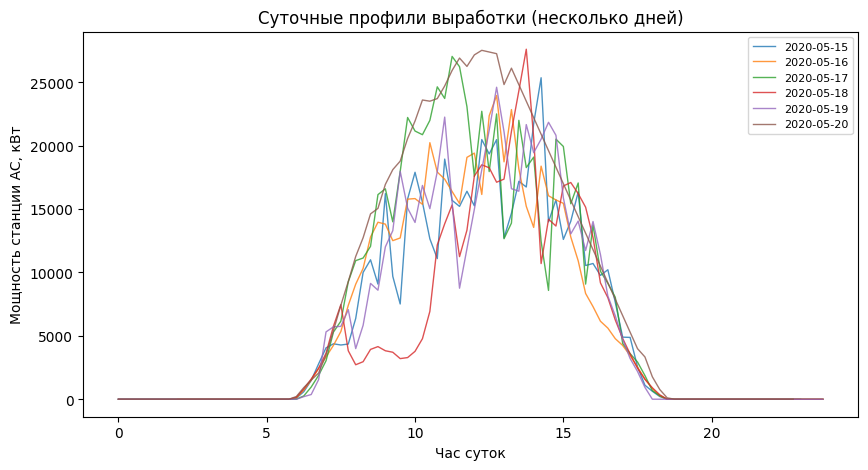

In [ ]:
df["date"] = df["DATE_TIME"].dt.date
df["hour"] = df["DATE_TIME"].dt.hour + df["DATE_TIME"].dt.minute/60

plt.figure(figsize=(10,5))
for d in sorted(df["date"].unique())[:6]:
    sub = df[df["date"]==d]
    plt.plot(sub["hour"], sub["AC_POWER"], lw=1, alpha=0.8, label=str(d))
plt.xlabel("Час суток"); plt.ylabel("Мощность станции AC, кВт")
plt.title("Суточные профили выработки (несколько дней)")
plt.legend(fontsize=8); plt.show()

## 3. Феринж через pvlib: геометрия Солнца и ясное небо

Здесь главный новый навык. Имея только момент времени и координаты станции, `pvlib` восстанавливает:
- **положение Солнца** — высоту над горизонтом (elevation), зенитный угол и азимут. Высота Солнца напрямую задаёт, сколько в принципе может прийти энергии;
- **clear-sky модель** — сколько освещённости (GHI) было бы при идеально ясном небе. Это физический «потолок» выработки в данный момент.

Сравнение реальной выработки с clear-sky как раз и показывает влияние облаков. Добавим ещё простые временные признаки (час, день года) и лаги недавней генерации — они понадобятся в конце.

Замечание: температура модуля и измеренная инсоляция тоже частично несут информацию об облачности (модуль греется на солнце). В настоящем прогнозе «на завтра» этих замеров нет — там брали бы прогноз погоды. Поэтому основную модель строим на астрономии + температуре, а измеренную инсоляцию покажем отдельно как «потолок».

In [ ]:
from pvlib.location import Location

# ПРИБЛИЗИТЕЛЬНЫЕ координаты станции (Индия). Для своего проекта поставьте реальные.
LAT, LON, TZ, ALT = 13.0, 77.6, "Asia/Kolkata", 900
loc = Location(LAT, LON, TZ, ALT)

# индекс времени с часовым поясом
idx = pd.DatetimeIndex(df["DATE_TIME"]).tz_localize(TZ)
solpos = loc.get_solarposition(idx)
clearsky = loc.get_clearsky(idx)

df["solar_elevation"] = solpos["apparent_elevation"].values
df["solar_zenith"]    = solpos["zenith"].values
df["solar_azimuth"]   = solpos["azimuth"].values
df["clearsky_ghi"]    = clearsky["ghi"].values
df["dayofyear"]       = idx.dayofyear

# лаги недавней генерации (15 минут и 1 час назад) — пригодятся для "учёта времени"
df["ac_lag1"] = df["AC_POWER"].shift(1)
df["ac_lag4"] = df["AC_POWER"].shift(4)
df[["DATE_TIME","AC_POWER","clearsky_ghi","solar_elevation","AMBIENT_TEMPERATURE"]].head()

,DATE_TIME,AC_POWER,clearsky_ghi,solar_elevation,AMBIENT_TEMPERATURE
0,2020-05-15 00:00:00,0.0,0.0,-57.889630,25.184316
1,2020-05-15 00:15:00,0.0,0.0,-58.127789,25.084589
2,2020-05-15 00:30:00,0.0,0.0,-57.938880,24.935753
3,2020-05-15 00:45:00,0.0,0.0,-57.330324,24.846130
4,2020-05-15 01:00:00,0.0,0.0,-56.324892,24.621525


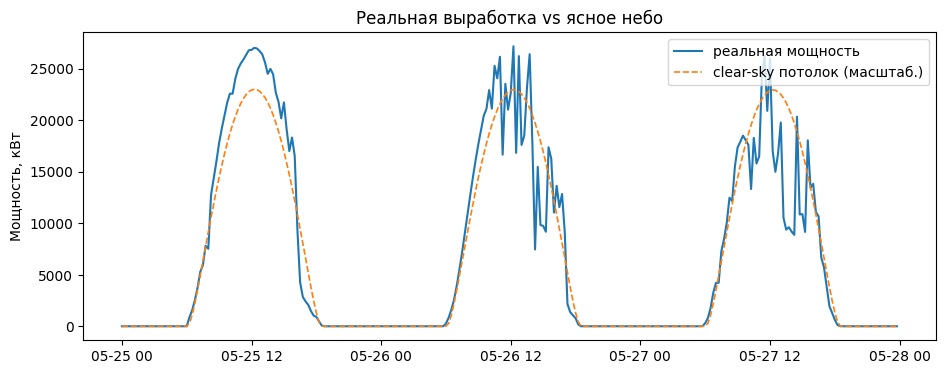

In [ ]:
# Реальная выработка против clear-sky потолка: ясный день гладко повторяет clear-sky,
# облачный — проваливается под него.
fig, ax = plt.subplots(figsize=(11,4))
sample_days = sorted(df["date"].unique())[10:13]
sub = df[df["date"].isin(sample_days)]
ax.plot(sub["DATE_TIME"], sub["AC_POWER"], label="реальная мощность", lw=1.5)
scale = sub["AC_POWER"].sum() / sub["clearsky_ghi"].clip(lower=1).sum()
ax.plot(sub["DATE_TIME"], scale*sub["clearsky_ghi"], "--", label="clear-sky потолок (масштаб.)", lw=1.2)
ax.set_ylabel("Мощность, кВт"); ax.set_title("Реальная выработка vs ясное небо"); ax.legend()
plt.show()

## 4. Постановка задачи и деление выборки

Цель — предсказать мощность станции AC. Работаем только по светлому времени (когда Солнце над горизонтом) — ночные нули задачу не делают интереснее, зато искусственно завышают метрики.

Сквозная тема курса — утечка, но здесь она в **временном** виде. Данные — это временной ряд, поэтому делить случайным перемешиванием НЕЛЬЗЯ: так будущее протекает в прошлое. Делим **хронологически**: обучаемся на ранних днях, проверяемся на последних. Это и есть честная имитация прогноза.

In [ ]:
# светлое время и убираем строки с пустыми лагами
data = df[df["solar_elevation"] > 0].dropna(subset=["ac_lag1","ac_lag4"]).copy()

# хронологический сплит: последние 7 дней в тест
cutoff = data["DATE_TIME"].max() - pd.Timedelta(days=7)
train = data[data["DATE_TIME"] <= cutoff]
test  = data[data["DATE_TIME"] >  cutoff]
print(f"train: {len(train)} точек | test: {len(test)} точек (последние 7 дней)")

y_train = train["AC_POWER"].values
y_test  = test["AC_POWER"].values

from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
results = {}
def report(name, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)
    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}
    print(f"{name:42s} MAE={mae:7.1f}  RMSE={rmse:7.1f}  R2={r2:.3f}")

train: 1346 точек | test: 359 точек (последние 7 дней)


## 5. Baseline: физика ясного неба

Самый честный физический baseline: считаем, что мощность пропорциональна clear-sky освещённости, и подбираем один коэффициент масштаба по train. Никакого обучения, чистая физика. Любая ML-модель должна его побеждать — иначе она не учит ничего сверх геометрии Солнца.

In [ ]:
k = y_train.sum() / train["clearsky_ghi"].sum()
report("Baseline: clear-sky x k", k * test["clearsky_ghi"].values)

Baseline: clear-sky x k                    MAE= 2930.4  RMSE= 3957.7  R2=0.722


## 6. Трек: LightGBM на астрономических и погодных признаках

Тот же LightGBM, что в ветре и батареях. Признаки — геометрия Солнца, clear-sky потолок, время и температуры (без измеренной инсоляции, её держим как «потолок» на потом). Модель должна выучить и форму суточной горки, и температурный дрейф КПД.

In [ ]:
import lightgbm as lgb

astro = ["solar_elevation","solar_zenith","solar_azimuth","clearsky_ghi",
         "hour","dayofyear","AMBIENT_TEMPERATURE","MODULE_TEMPERATURE"]

lgbm = lgb.LGBMRegressor(n_estimators=400, learning_rate=0.05, num_leaves=31,
                         importance_type="gain", verbose=-1)
lgbm.fit(train[astro], y_train)
report("LightGBM: астрономия + температура", lgbm.predict(test[astro]))

LightGBM: астрономия + температура         MAE= 1570.5  RMSE= 2278.8  R2=0.908


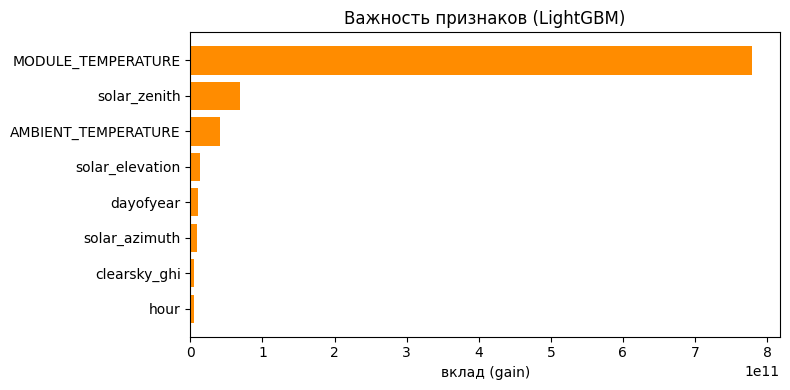

In [ ]:
# Важность признаков (аналог SHAP): на что опирается модель
imp = sorted(zip(astro, lgbm.feature_importances_), key=lambda t: t[1])
plt.figure(figsize=(8,4))
plt.barh([n for n,_ in imp], [v for _,v in imp], color="darkorange")
plt.title("Важность признаков (LightGBM)"); plt.xlabel("вклад (gain)")
plt.tight_layout(); plt.show()

## 7. Где табличный бустинг проигрывает времени

Главная трудность солнечного прогноза — облака, а они **коррелированы во времени**: если минуту назад набежало облако, скорее всего оно еще здесь. «Чистый» табличный LightGBM смотрит на каждый момент независимо и эту инерцию не использует.

Добавим лаги — мощность 15 минут и час назад. Это простой способ дать модели «память». Прирост зависит от данных: на этом наборе он небольшой, потому что температура модуля уже косвенно несет свежую информацию об инсоляции. По-настоящему учёт времени важен для честного прогноза «на час/день вперёд», когда недавних замеров у целевого момента нет (см. задания), и для последовательностных моделей (LSTM, как в батарейном занятии), которые читают всю историю; лаги — их облегченная имитация.

Для контраста добавим еще измеренную инсоляцию: она почти напрямую задаёт мощность, поэтому модель становится почти идеальной. Но в реальном прогнозе будущей инсоляции у вас нет — ее пришлось бы брать из прогноза погоды или спутника. Это показывает, где на самом деле спрятан сигнал.

In [ ]:
# + лаги (учёт времени)
lgbm_t = lgb.LGBMRegressor(n_estimators=400, learning_rate=0.05, num_leaves=31, verbose=-1)
lgbm_t.fit(train[astro+["ac_lag1","ac_lag4"]], y_train)
report("LightGBM: + лаги (учёт времени)", lgbm_t.predict(test[astro+["ac_lag1","ac_lag4"]]))

# + измеренная инсоляция (контраст: "потолок")
lgbm_i = lgb.LGBMRegressor(n_estimators=400, learning_rate=0.05, num_leaves=31, verbose=-1)
lgbm_i.fit(train[astro+["IRRADIATION"]], y_train)
report("LightGBM: + измеренная инсоляция", lgbm_i.predict(test[astro+["IRRADIATION"]]))

LightGBM: + лаги (учёт времени)            MAE= 1503.3  RMSE= 2231.4  R2=0.912
LightGBM: + измеренная инсоляция           MAE=  440.0  RMSE=  662.6  R2=0.992


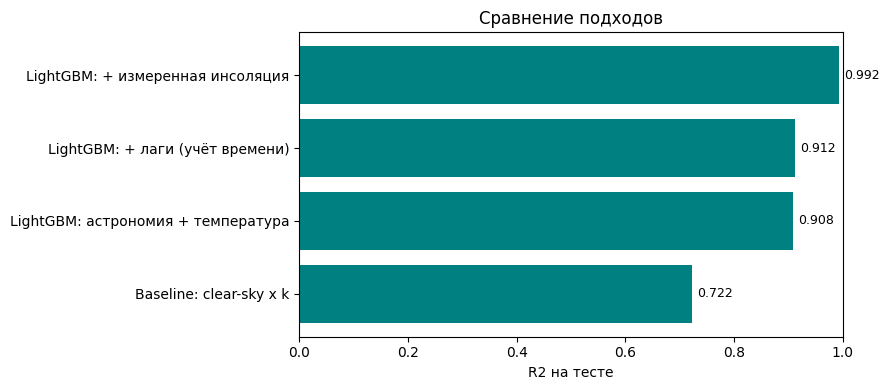

In [ ]:
# Сводка по всем подходам
names = list(results.keys())
r2s = [results[n]["R2"] for n in names]
plt.figure(figsize=(9,4))
plt.barh(names, r2s, color="teal")
plt.xlabel("R2 на тесте"); plt.title("Сравнение подходов"); plt.xlim(0,1)
for i,v in enumerate(r2s): plt.text(v+0.01, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

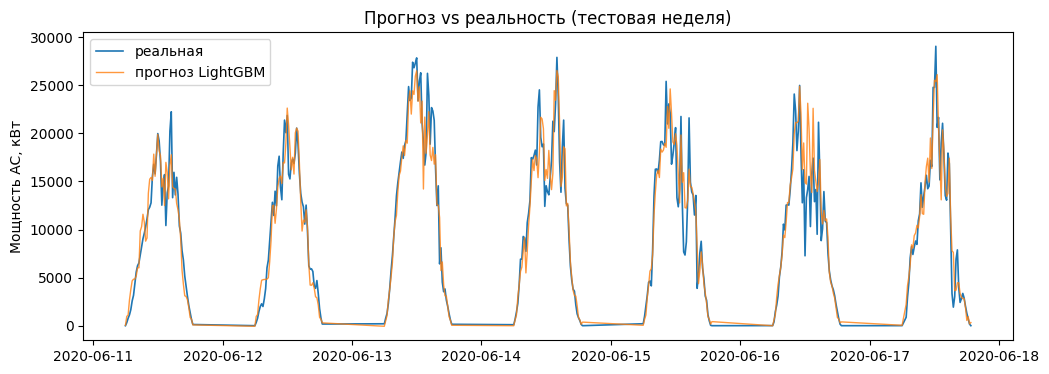

In [ ]:
# Как прогноз ложится на реальную кривую (тестовая неделя, модель астрономия+температура)
pred = lgbm.predict(test[astro])
plt.figure(figsize=(12,4))
plt.plot(test["DATE_TIME"].values, y_test, label="реальная", lw=1.2)
plt.plot(test["DATE_TIME"].values, pred, label="прогноз LightGBM", lw=1.0, alpha=0.8)
plt.ylabel("Мощность AC, кВт"); plt.title("Прогноз vs реальность (тестовая неделя)")
plt.legend(); plt.show()

## 8. Честный прогноз вперёд: сколько стоит недавнее наблюдение

В разделе 7 лаги почти не помогли — но это был нокаст (предсказывали «прямо сейчас»). По-настоящему ценность учёта времени видна в честном прогнозе **на горизонт H вперёд**: предсказываем мощность через H шагов, используя только то, что известно в момент прогноза:
- геометрию Солнца на целевой момент (она детерминирована — положение Солнца известно наперёд на любое время);
- последнее наблюдённое состояние станции (мощность и температура модуля H шагов назад).

Сравним две модели одного семейства: «только геометрия» (без памяти) и «геометрия + недавнее наблюдение». Разница между ними — это и есть цена недавней информации, и она быстро тает с горизонтом: облако, которое сейчас над станцией, через 15 минут скорее всего ещё здесь, а через час — уже нет.

горизонт  15 мин:  только геометрия R2=0.672 | +недавнее R2=0.826 | выигрыш +0.154
горизонт  30 мин:  только геометрия R2=0.672 | +недавнее R2=0.746 | выигрыш +0.074
горизонт  60 мин:  только геометрия R2=0.672 | +недавнее R2=0.680 | выигрыш +0.009
горизонт 120 мин:  только геометрия R2=0.672 | +недавнее R2=0.708 | выигрыш +0.037
горизонт 180 мин:  только геометрия R2=0.672 | +недавнее R2=0.690 | выигрыш +0.018
горизонт 360 мин:  только геометрия R2=0.672 | +недавнее R2=0.660 | выигрыш +-0.011


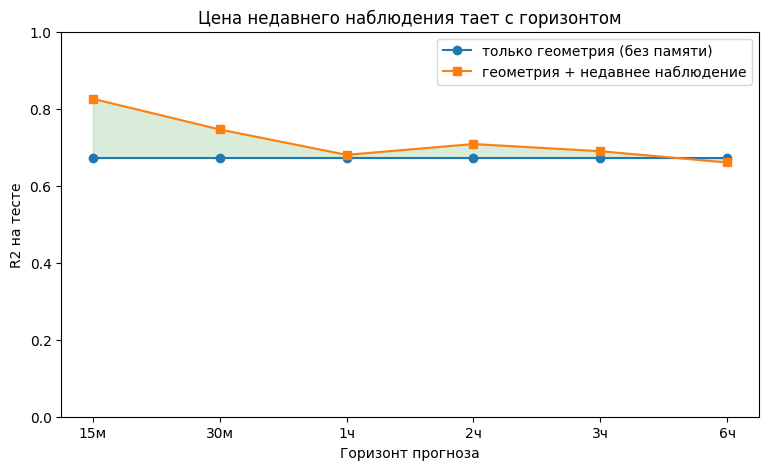

In [ ]:
known_ahead = ["solar_elevation","solar_zenith","solar_azimuth","clearsky_ghi","hour","dayofyear"]

def forecast_horizon(H):
    d = df.copy()
    d["power_origin"] = d["AC_POWER"].shift(H)              # мощность H шагов назад
    d["modt_origin"]  = d["MODULE_TEMPERATURE"].shift(H)
    d = d[d["solar_elevation"] > 0].dropna(subset=["power_origin"])
    cut = d["DATE_TIME"].max() - pd.Timedelta(days=7)
    tr, te = d[d["DATE_TIME"] <= cut], d[d["DATE_TIME"] > cut]
    ytr, yte = tr["AC_POWER"].values, te["AC_POWER"].values
    params = dict(n_estimators=400, learning_rate=0.05, num_leaves=15,
                  min_child_samples=30, verbose=-1)
    only_geo   = lgb.LGBMRegressor(**params).fit(tr[known_ahead], ytr)
    geo_recent = lgb.LGBMRegressor(**params).fit(tr[known_ahead+["power_origin","modt_origin"]], ytr)
    return (r2_score(yte, only_geo.predict(te[known_ahead])),
            r2_score(yte, geo_recent.predict(te[known_ahead+["power_origin","modt_origin"]])))

horizons = [1, 2, 4, 8, 12, 24]          # шаги по 15 минут: от 15 минут до 6 часов
labels   = ["15м","30м","1ч","2ч","3ч","6ч"]
geo_r2, rec_r2 = [], []
for H in horizons:
    a, b = forecast_horizon(H)
    geo_r2.append(a); rec_r2.append(b)
    print(f"горизонт {H*15:>3d} мин:  только геометрия R2={a:.3f} | +недавнее R2={b:.3f} | выигрыш +{b-a:.3f}")

plt.figure(figsize=(9,5))
plt.plot(labels, geo_r2, "o-", label="только геометрия (без памяти)")
plt.plot(labels, rec_r2, "s-", label="геометрия + недавнее наблюдение")
plt.fill_between(range(len(labels)), geo_r2, rec_r2, alpha=0.15, color="green")
plt.xlabel("Горизонт прогноза"); plt.ylabel("R2 на тесте")
plt.title("Цена недавнего наблюдения тает с горизонтом"); plt.ylim(0,1); plt.legend()
plt.show()

Зелёная зона — выигрыш от памяти. На 15 минут вперёд недавнее наблюдение даёт большой прирост (облако ещё на месте), к часу он почти исчезает, а дальше остаётся одна геометрия. Вот это и есть «учёт времени» в чистом виде: его ценность измерима и быстро убывает. Поэтому прогнозы на часы-сутки опираются не на инерцию, а на прогноз облачности (погодные модели, спутник), а для извлечения временной структуры берут последовательностные сети (LSTM, как в батарейном занятии).

## 9. Что мы поняли и задания

- **Тот же инструмент** LightGBM не изменился, но сигнал теперь добывается из физики: положение Солнца и clear-sky модель через `pvlib`.
- **Физический baseline — точка отсчёта.** Clear-sky масштабирование задаёт «потолок без облаков»; ML должна его обыгрывать, иначе она не выучила ничего сверх геометрии.
- **Время имеет значение.** Облачность инерционна, поэтому лаги недавней генерации заметно поднимают точность — здесь чистый табличный подход (момент за моментом) проигрывает методам с памятью; их естественное развитие — LSTM из батарейного занятия.
- **Где спрятан сигнал.** Измеренная инсоляция почти решает задачу, но в реальном прогнозе её нет — это объясняет, почему прогноз погоды/спутник так важны для солнца.
- **Утечка во времени.** Временной ряд делим хронологически, а не перемешиванием.

### Задания
**Plant_2.** Повторите на втором заводе из датасета. Переносятся ли выводы?